# Analiza obrazów przy pomocy sieci konwolucyjnych

### Zakres ćwiczeń
- Wykorzystanie konwolucyjnych sieci neuronowych (CNN) do analizy obrazów
- Pobranie gotowego modelu przy pomocy biblioteki Tensorflow Datasets
- Przetwarzania i udostępnianie danych przy pomocy *Dataset API*
- Wykorzystanie gotowych modeli do uczenia transferowego

In [ ]:
#imports
import matplotlib.pyplot as plt
import tensorflow as tf

### Ładowanie danych

In [ ]:
import tensorflow_datasets as tfds
[test_set_raw, valid_set_raw, train_set_raw], info = tfds.load(
    "tf_flowers", split=['train[:10%]', 'train[10%:25%]', 'train[25%:]'], as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.K13BV0_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


In [ ]:
class_names = info.features['label'].names
n_classes = info.features['label'].num_classes
dataset_size = info.splits['train'].num_examples

In [ ]:
print(f"class_names = {class_names}\nn_classes = {n_classes}\ndataset_size = {dataset_size}")

class_names = ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
n_classes = 5
dataset_size = 3670


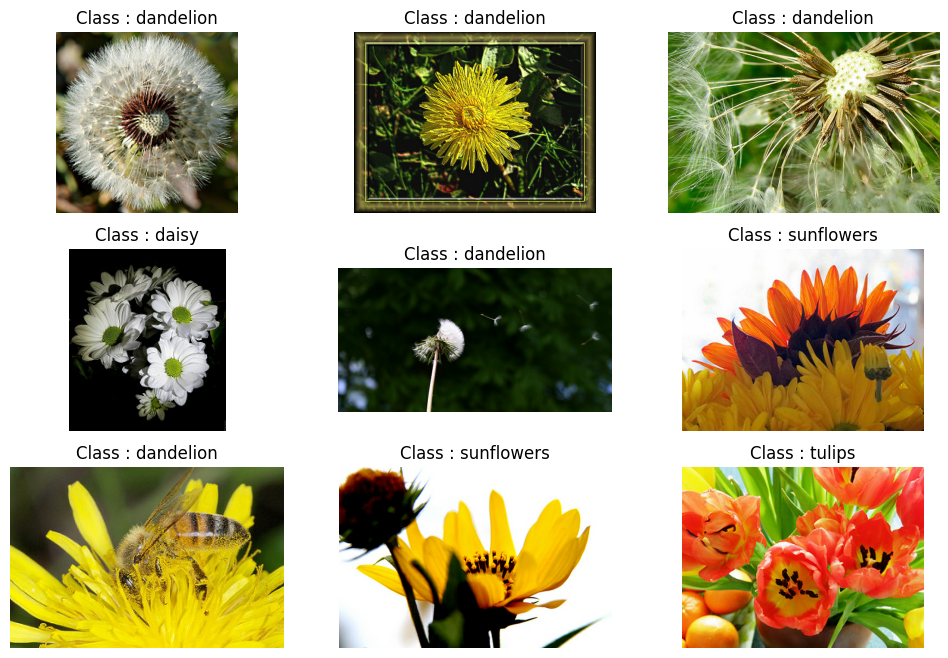

In [ ]:
# Wyświetlenie kilku przykładowych obrazów
plt.figure(figsize=(12,8))
index=0

sample_images = train_set_raw.take(9)

for image, label in sample_images:
  index +=1
  plt.subplot(3, 3, index)
  plt.imshow(image)
  plt.title("Class : {}".format(class_names[label]))
  plt.axis("off")
plt.show(block=False)

### Przygotowanie danych

In [ ]:
# Funkcja skalująca obraz do pożądanego rozmiaru
def preprocess(image, label):
  resized_image = tf.image.resize(image, [224, 224])
  return resized_image, label

In [ ]:
batch_size = 32
train_set = train_set_raw.map(preprocess).shuffle(dataset_size).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


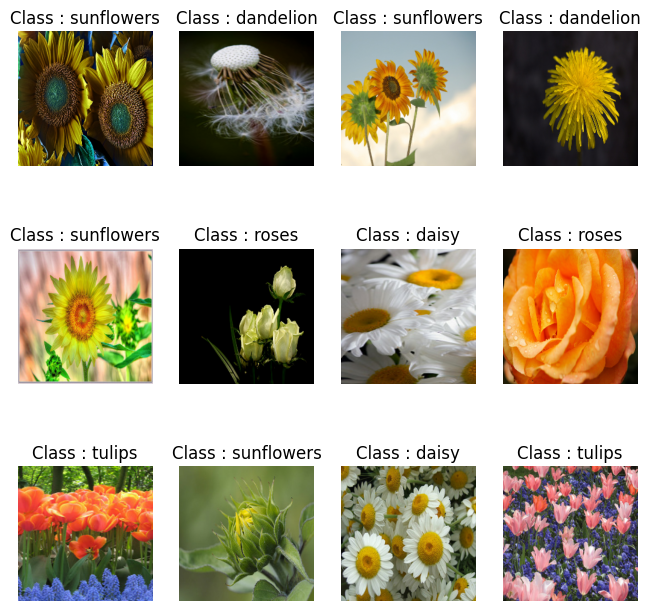

In [ ]:
# Wyświetlenie danych po przetworzeniu
plt.figure(figsize=(8,8))
sample_batch = train_set.take(1)
print(sample_batch)

for X_batch, y_batch in sample_batch:
  for index in range(12):
    plt.subplot(3, 4, index + 1)
    plt.imshow(X_batch[index]/255.0)
    plt.title("Class : {}".format(class_names[y_batch[index]]))
    plt.axis("off")
plt.show()

### Budowa sieci

In [ ]:
# Checkpoint
from tensorflow.keras.callbacks import ModelCheckpoint
checkpoint = ModelCheckpoint(filepath='model.keras',
                             monitor='val_loss',
                             save_best_only=True,
                             save_weights_only=False,
                             verbose=-1)

In [ ]:
model = tf.keras.models.Sequential(
    [tf.keras.layers.Rescaling(1.0/255, input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(filters=16, kernel_size=5, padding='SAME', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='SAME', activation='relu'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='SAME', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='SAME', activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(units=5, activation='softmax')]
)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,211,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,245,253 (12.38 MB)

 Trainable params: 3,245,253 (12.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(train_set, epochs=5, validation_data=valid_set, callbacks=[checkpoint])

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 257s 3s/step - accuracy: 0.3515 - loss: 1.4969 - val_accuracy: 0.4955 - val_loss: 1.1696
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 260s 3s/step - accuracy: 0.5283 - loss: 1.1168 - val_accuracy: 0.5172 - val_loss: 1.1317
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.5763 - loss: 1.0540 - val_accuracy: 0.6298 - val_loss: 0.9818
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 252s 3s/step - accuracy: 0.6509 - loss: 0.9059 - val_accuracy: 0.6225 - val_loss: 0.9219
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 241s 3s/step - accuracy: 0.7181 - loss: 0.7551 - val_accuracy: 0.6497 - val_loss: 0.9013


In [ ]:
from tensorflow.keras.models import load_model
model = load_model('model.keras')
model.fit(train_set, epochs=5, validation_data=valid_set, callbacks=[checkpoint])

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 246s 3s/step - accuracy: 0.7990 - loss: 0.5647 - val_accuracy: 0.6443 - val_loss: 0.9769
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 270s 3s/step - accuracy: 0.8639 - loss: 0.3908 - val_accuracy: 0.6588 - val_loss: 0.9706
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 250s 3s/step - accuracy: 0.9005 - loss: 0.2977 - val_accuracy: 0.6425 - val_loss: 1.2461
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 253s 3s/step - accuracy: 0.9320 - loss: 0.1956 - val_accuracy: 0.6642 - val_loss: 1.4683
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 249s 3s/step - accuracy: 0.9492 - loss: 0.1480 - val_accuracy: 0.6370 - val_loss: 1.5986


In [ ]:
import pickle
model = load_model("model.keras")
test_loss, test_acc = model.evaluate(test_set)
train_loss, train_acc = model.evaluate(train_set)
val_loss, val_acc = model.evaluate(valid_set)

result1 = (train_acc, val_acc, test_acc)
with open("simple_cnn_acc.pkl", 'wb') as file:
  pickle.dump(result1, file)
model.save("simple_cnn_flowers.keras")

print(f"Train:  acc={train_acc}, loss={train_loss}\nTest:   acc={test_acc}, loss={test_loss}\nValid:  acc={val_acc}, loss={val_loss}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 831ms/step - accuracy: 0.6672 - loss: 0.9050
86/86 ━━━━━━━━━━━━━━━━━━━━ 71s 802ms/step - accuracy: 0.8291 - loss: 0.5354
18/18 ━━━━━━━━━━━━━━━━━━━━ 17s 956ms/step - accuracy: 0.6495 - loss: 0.9012
Train:  acc=0.8273982405662537, loss=0.5257886648178101
Test:   acc=0.6730245351791382, loss=0.8649845123291016
Valid:  acc=0.6497277617454529, loss=0.901282548904419


## Uczenie transferowe

Zostanie wykorzystana gotowa sieć [Xception](https://www.tensorflow.org/api_docs/python/tf/keras/applications/xception)

### Przygotowanie danych

In [ ]:
def preprocess(image, label):
  resized_image = tf.image.resize(image, [224, 224])
  final_image = tf.keras.applications.xception.preprocess_input(resized_image)
  return final_image, label

In [ ]:
batch_size = 32
train_set = train_set_raw.map(preprocess).shuffle(dataset_size).batch(batch_size).prefetch(1)
valid_set = valid_set_raw.map(preprocess).batch(batch_size).prefetch(1)
test_set = test_set_raw.map(preprocess).batch(batch_size).prefetch(1)

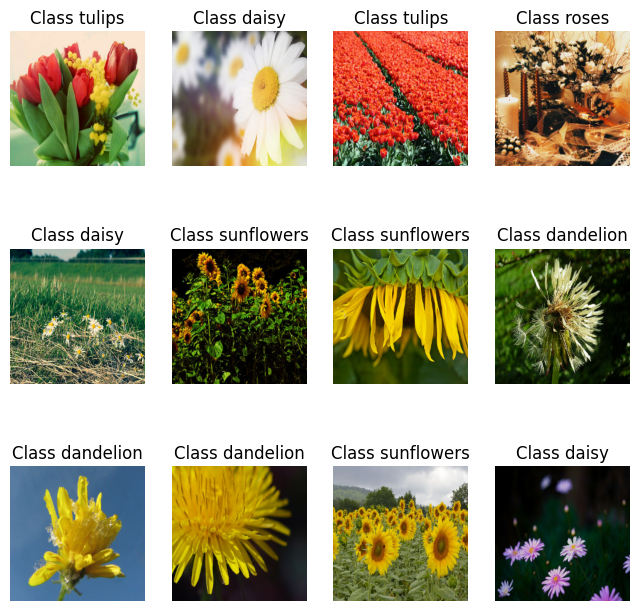

In [ ]:
plt.figure(figsize=(8,8))
sample_batch = train_set.take(1)
for X_batch, y_batch in sample_batch:
  for index in range(12):
    plt.subplot(3,4,index+1)
    plt.imshow(X_batch[index]/2 + 0.5)
    plt.title("Class {}".format(class_names[y_batch[index]]))
    plt.axis("off")
plt.show()

### Budowa sieci

In [ ]:
%pip install graphviz
%pip install pydot
base_model = tf.keras.applications.xception.Xception(weights="imagenet", include_top=False)
# Nie działa na colabie
#tf.keras.utils.plot_model(base_model, to_file="base_model.png")

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer_1[0]… │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [ ]:
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation='softmax')(avg)
model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

In [ ]:
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.2, momentum=0.9)
model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
history = model.fit(train_set, validation_data=valid_set, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 801s 9s/step - accuracy: 0.6897 - loss: 1.8337 - val_accuracy: 0.8421 - val_loss: 1.4529
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 771s 9s/step - accuracy: 0.9065 - loss: 0.6032 - val_accuracy: 0.8675 - val_loss: 1.0631
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 743s 9s/step - accuracy: 0.9192 - loss: 0.3953 - val_accuracy: 0.8621 - val_loss: 1.5862
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 741s 9s/step - accuracy: 0.9415 - loss: 0.2721 - val_accuracy: 0.8621 - val_loss: 1.1560
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 744s 9s/step - accuracy: 0.9724 - loss: 0.0994 - val_accuracy: 0.8711 - val_loss: 1.0636


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

In [ ]:
for layer in base_model.layers:
  layer.trainable = True
model.compile(loss='sparse_categorical_crossentropy', optimizer=tf.keras.optimizers.SGD(learning_rate=0.2, momentum=0.9), metrics=['accuracy'])
history = model.fit(train_set, validation_data=valid_set, epochs=10, callbacks=[es])

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2703s 31s/step - accuracy: 0.5774 - loss: 1.1500 - val_accuracy: 0.1815 - val_loss: 188.5176
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2613s 30s/step - accuracy: 0.6083 - loss: 0.9960 - val_accuracy: 0.4338 - val_loss: 1.9392
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2609s 30s/step - accuracy: 0.7291 - loss: 0.7263 - val_accuracy: 0.5808 - val_loss: 1.1599
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 2663s 30s/step - accuracy: 0.7767 - loss: 0.6292 - val_accuracy: 0.4574 - val_loss: 2.2072
Epoch 5/10
65/86 ━━━━━━━━━━━━━━━━━━━━ 10:02 29s/step - accuracy: 0.8357 - loss: 0.4391

In [ ]:
test_loss, test_acc = model.evaluate(test_set)
train_loss, train_acc = model.evaluate(train_set)
val_loss, val_acc = model.evaluate(valid_set)

result2 = (train_acc, val_acc, test_acc)
with open("xception_acc.pkl", 'wb') as file:
  pickle.dump(result2, file)
model.save("xception_flowers.keras")

print(f"Train:  acc={train_acc}, loss={train_loss}\nTest:   acc={test_acc}, loss={test_loss}\nValid:  acc={val_acc}, loss={val_loss}")

NameError: name 'model' is not defined